<a href="https://colab.research.google.com/github/ealger22/main/blob/CSC-302-Data-Visualization/HW5_AODC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


##Q3
Please follow the instructions below and inspect the outputs before you proceed. You can always check this original final to compare your results in your own copy.

In [3]:
# Load the CSV from the correct path
house = pd.read_csv('/content/drive/MyDrive/ColabFiles/house_prices.csv')

# Preview data
house.head()


,Unnamed: 0,date,state,unemploy_perc,house_price_index,house_price_perc
0,1,1976-01-01,Alabama,6.7,37.138285,0.040405
1,2,1976-02-01,Alabama,6.7,37.756437,0.051806
2,3,1976-03-01,Alabama,6.6,38.276319,0.059302
3,4,1976-04-01,Alabama,6.5,38.596135,0.059585
4,5,1976-05-01,Alabama,6.4,38.740517,0.055723


a) For the states below, please select the rows from the house dataframe, and consider converting the date column to date data type as it may be coming in string format. Then use the head function to preview your new dataframe.

In [4]:
# Step 1: Define target states
states = ['Michigan', 'California', 'Texas', 'Indiana']

# Step 2: Filter the dataframe to only include those states
filtered_house = house[house['state'].isin(states)].copy()

# Step 3: Convert the 'date' column to datetime format (in case it's a string)
filtered_house['date'] = pd.to_datetime(filtered_house['date'])

# Step 4: Preview the filtered and updated dataframe
filtered_house.head()


,Unnamed: 0,date,state,unemploy_perc,house_price_index,house_price_perc
2016,2017,1976-01-01,California,9.1,17.908764,0.139067
2017,2018,1976-02-01,California,9.1,18.117587,0.148485
2018,2019,1976-03-01,California,9.0,18.379530,0.151243
2019,2020,1976-04-01,California,9.0,18.673067,0.147308
2020,2021,1976-05-01,California,8.9,18.899995,0.143167


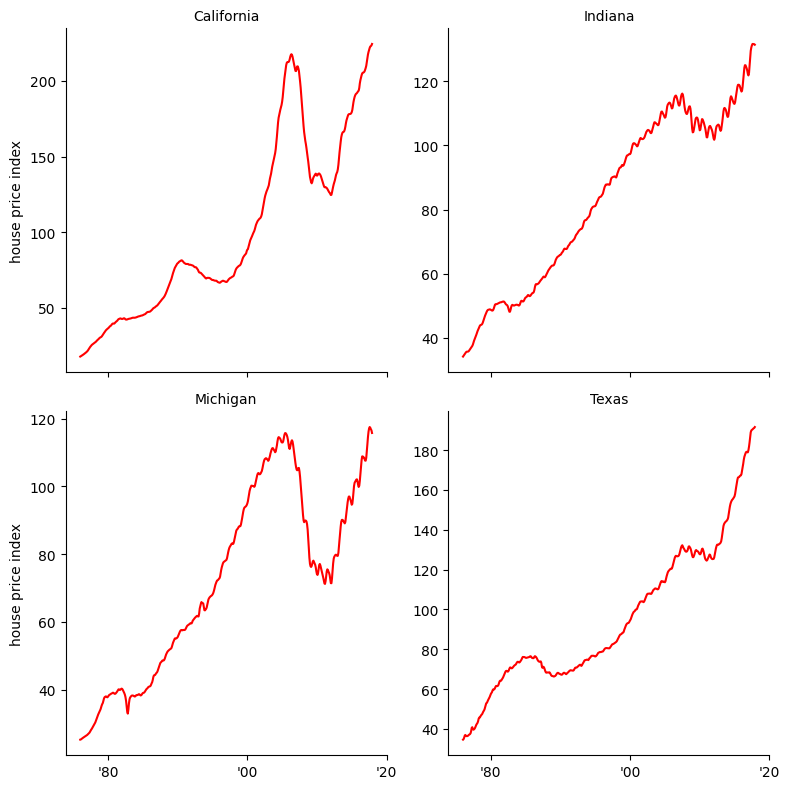

In [5]:
states = ['Michigan', 'California', 'Texas', 'Indiana']
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Make sure 'date' is in datetime format (safe even if you've done it already)
filtered_house['date'] = pd.to_datetime(filtered_house['date'])

# Create the FacetGrid plot
g = sns.FacetGrid(filtered_house, col='state', col_wrap=2, height=4, sharey=False)

# Map red line plots for house_price_index over time
g.map_dataframe(sns.lineplot, x='date', y='house_price_index', color='red')

# Customize x-axis ticks to show only specific years
for ax in g.axes.flat:
    ax.set_xticks(pd.to_datetime(['1980', '2000', '2020']))
    ax.set_xticklabels(["'80", "'00", "'20"])

# Set labels and titles
g.set_axis_labels("", "house price index")  # no x-axis label, y-axis labeled
g.set_titles("{col_name}")  # each subplot titled with state name
plt.tight_layout()
plt.show()



b) Use the FacetGrid from seaborn to create line plots to represent house_price_index for each state. Please make the line color red, set ticks on x axis for years ['1980', '2000', '2020'], which you may have to convert date type again, put those years as labels, and set the titles for each small plot to their state names. In addition, set the y label to 'house price index' and remove the x label since it's obvious that these are years.

c) Draw a lineplot for 'house price perc', but color them based on the 'state' name which will have four lines in a single plot. Set a legend which will be at the bottom of your graph and have them horizantally positioned next to eachother. Again, set the y label to house_price_perc and remove the x label since it's obvious. (Note that my y label is still showing index. Please ignore that.)

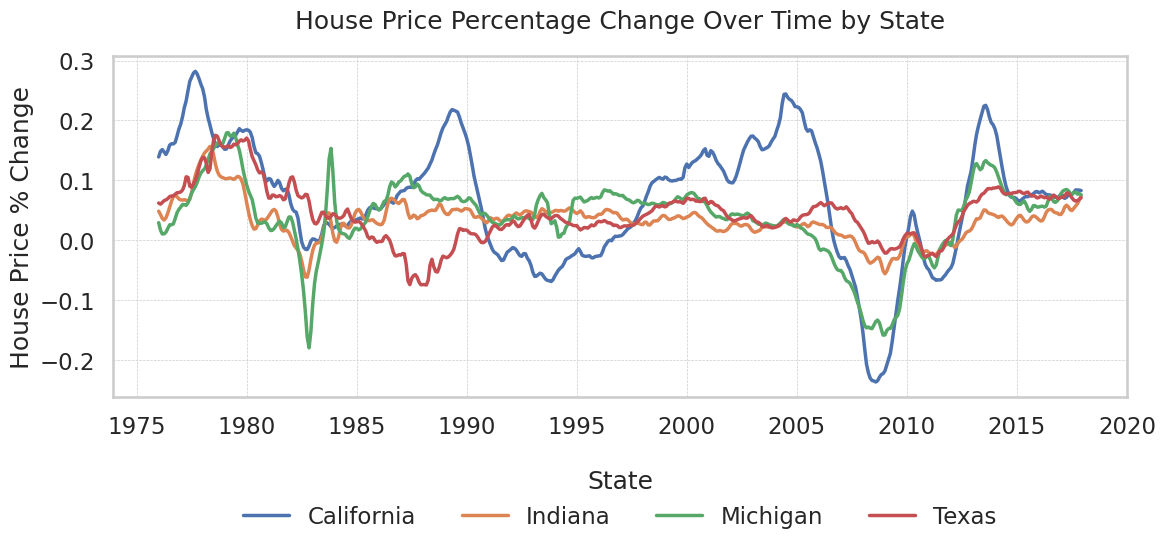

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set seaborn style
sns.set(style="whitegrid", context="talk")

# Set up figure size and initialize plot
plt.figure(figsize=(12, 6))

# Lineplot: house_price_perc over time, colored by state
sns.lineplot(data=filtered_house, x='date', y='house_price_perc', hue='state', linewidth=2.5)

# Remove x-axis label
plt.xlabel("")

# Y-axis label
plt.ylabel("House Price % Change")

# Title
plt.title("House Price Percentage Change Over Time by State", fontsize=18, pad=20)

# Move legend to the bottom center and format horizontally
plt.legend(title='State', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, frameon=False)

# Add grid and improve spacing
plt.grid(True, which='major', linestyle='--', linewidth=0.5)
plt.tight_layout()

# Display plot
plt.show()



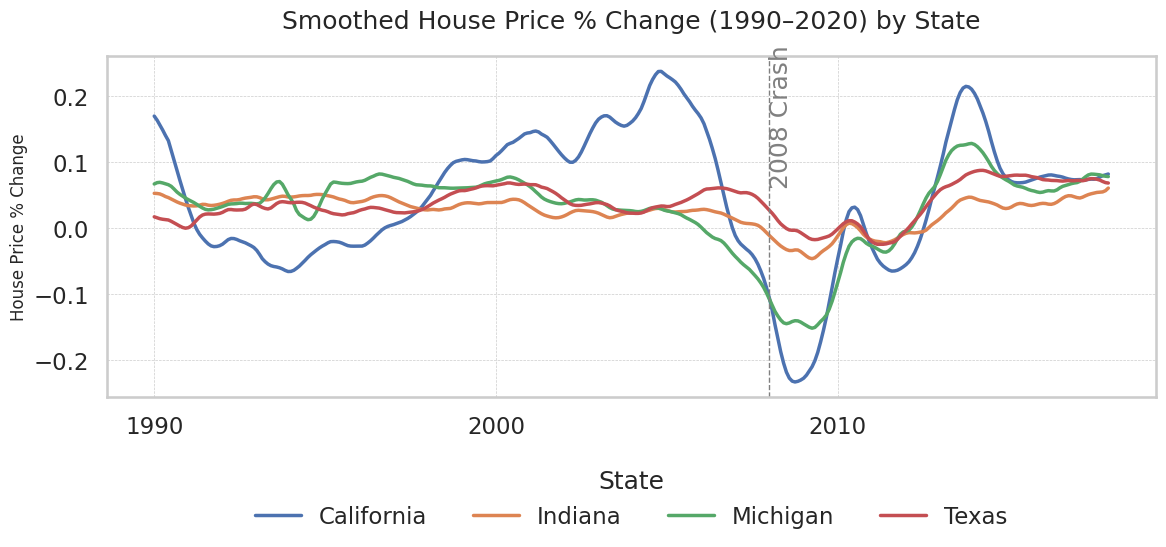

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Ensure 'date' is in datetime format (necessary for proper time-based plotting)
filtered_house['date'] = pd.to_datetime(filtered_house['date'])

# 2. Focus on a more readable and relevant time range: 1990–2020
# This helps reduce clutter on the x-axis and emphasizes modern trends
filtered_recent = filtered_house[filtered_house['date'] >= '1990-01-01'].copy()

# 3. Smooth the data using a rolling average (6-month window)
# This makes the line less noisy and trends easier to interpret
filtered_recent['smoothed_perc'] = filtered_recent.groupby('state')['house_price_perc'] \
    .transform(lambda x: x.rolling(window=6, min_periods=1).mean())

# 4. Use seaborn's whitegrid style with larger fonts for a cleaner, more professional look
sns.set(style="whitegrid", context="talk")

# 5. Create the plot using smoothed house price percentage values
plt.figure(figsize=(12, 6))  # Wider figure improves readability
sns.lineplot(data=filtered_recent, x='date', y='smoothed_perc', hue='state', linewidth=2.5)

# 6. Improve x-axis formatting: show ticks every 10 years
# This reduces visual noise and keeps labels clear and aligned
plt.gca().xaxis.set_major_locator(mdates.YearLocator(10))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# 7. Optional: Add a vertical line and label to mark the 2008 housing crash
# Helps highlight significant economic events that impacted housing
plt.axvline(pd.to_datetime('2008-01-01'), color='gray', linestyle='--', linewidth=1)
plt.text(pd.to_datetime('2008-01-01'), 0.17, '2008 Crash', rotation=90,
         verticalalignment='center', color='gray')

# 8. Customize axis labels and title
# Removing the x-axis label keeps the chart uncluttered since years are obvious
plt.xlabel("")  # As per instructions
plt.ylabel("House Price % Change", fontsize=12)
plt.title("Smoothed House Price % Change (1990–2020) by State", fontsize=18, pad=20)

# 9. Move the legend to the bottom and lay it out horizontally
# This saves space and makes comparison between states easier
plt.legend(title='State', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, frameon=False)

# 10. Add grid lines for better alignment across the time axis
plt.grid(True, linestyle='--', linewidth=0.5)

# 11. Use tight layout to prevent clipping of labels and titles
plt.tight_layout()

# 12. Display the final chart
plt.show()



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




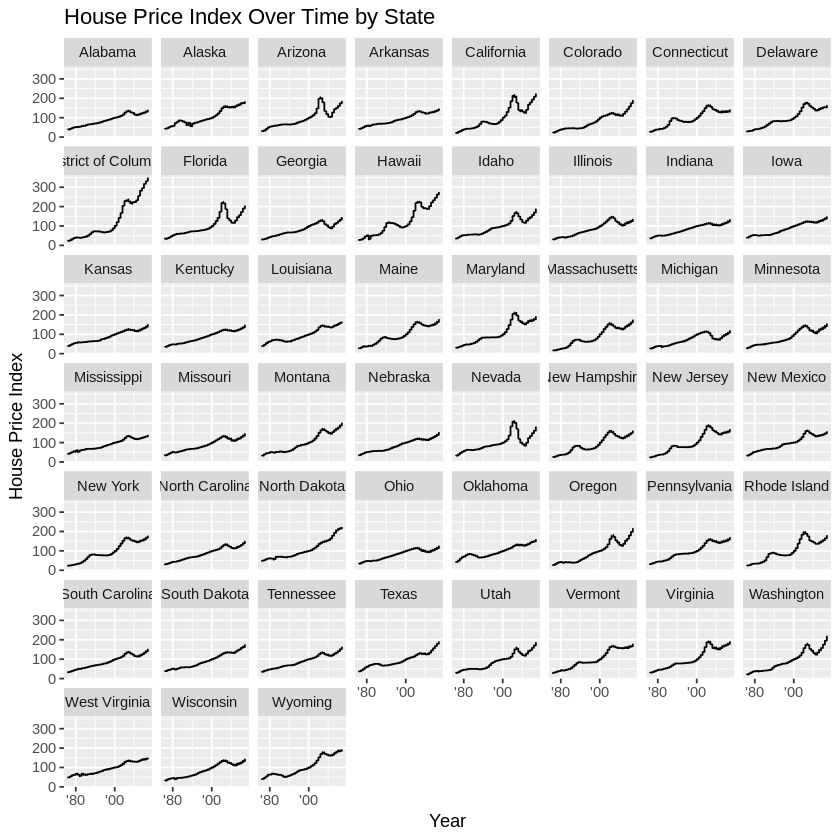

In [4]:
# Load libraries
library(ggplot2)
library(tidyr)
library(dplyr)
library(lubridate)

# Load data
load("/content/drive/MyDrive/ColabFiles/house_prices.rda")

# Add year column
house_prices$year <- year(house_prices$date)

# Plot
ggplot(house_prices, aes(x = year, y = house_price_index)) +
  geom_line() +
  facet_wrap(~ state) +
  scale_x_continuous(breaks = c(1980, 2000, 2020), labels = c("'80", "'00", "'20")) +
  labs(title = "House Price Index Over Time by State", x = "Year", y = "House Price Index")


In [5]:
library(tidyr)

house_reshaped <- house_prices %>%
  gather(key = "measure", value = "value", house_price_index, unemploy_perc)
head(house_reshaped)


date,state,house_price_perc,year,measure,value
<date>,<chr>,<dbl>,<dbl>,<chr>,<dbl>
1976-01-01,Alabama,0.04040541,1976,house_price_index,37.13829
1976-02-01,Alabama,0.05180597,1976,house_price_index,37.75644
1976-03-01,Alabama,0.05930233,1976,house_price_index,38.27632
1976-04-01,Alabama,0.05958458,1976,house_price_index,38.59613
1976-05-01,Alabama,0.05572338,1976,house_price_index,38.74052
1976-06-01,Alabama,0.05359368,1976,house_price_index,38.79723


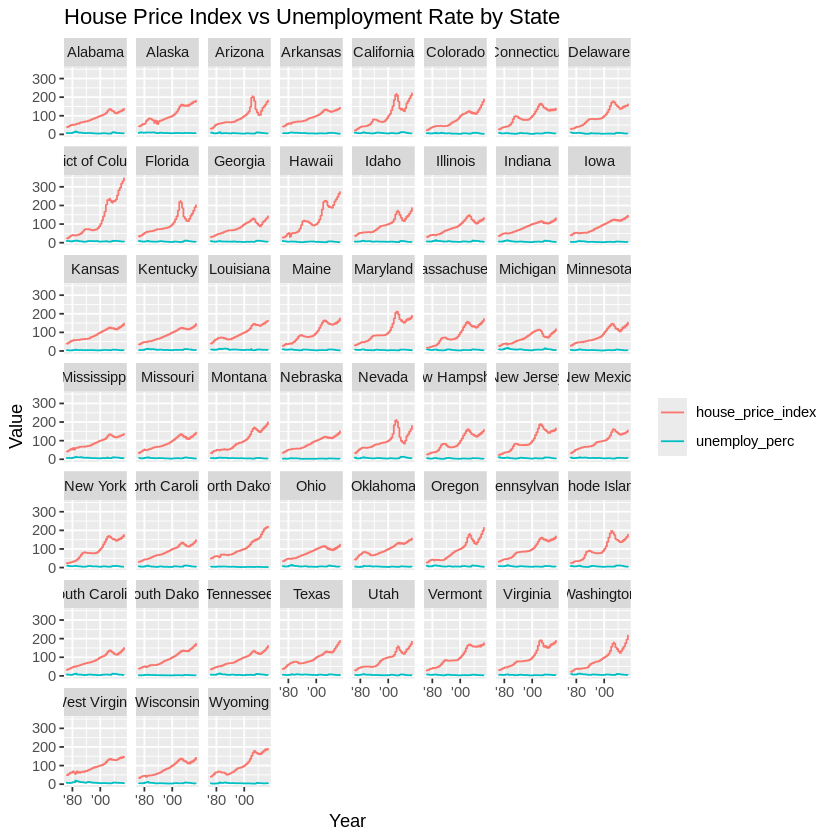

In [6]:
ggplot(house_reshaped, aes(x = year(date), y = value, color = measure)) +
  geom_line() +
  facet_wrap(~ state) +
  scale_x_continuous(breaks = c(1980, 2000, 2020), labels = c("'80", "'00", "'20")) +
  labs(title = "House Price Index vs Unemployment Rate by State", y = "Value", x = "Year") +
  theme(legend.title = element_blank())


In [7]:
library(tidyr)

# Reshape the data to long format
house_reshaped <- house_prices %>%
  gather(key = "measure", value = "value", house_price_index, unemploy_perc)

# Preview the reshaped data
head(house_reshaped)


date,state,house_price_perc,year,measure,value
<date>,<chr>,<dbl>,<dbl>,<chr>,<dbl>
1976-01-01,Alabama,0.04040541,1976,house_price_index,37.13829
1976-02-01,Alabama,0.05180597,1976,house_price_index,37.75644
1976-03-01,Alabama,0.05930233,1976,house_price_index,38.27632
1976-04-01,Alabama,0.05958458,1976,house_price_index,38.59613
1976-05-01,Alabama,0.05572338,1976,house_price_index,38.74052
1976-06-01,Alabama,0.05359368,1976,house_price_index,38.79723


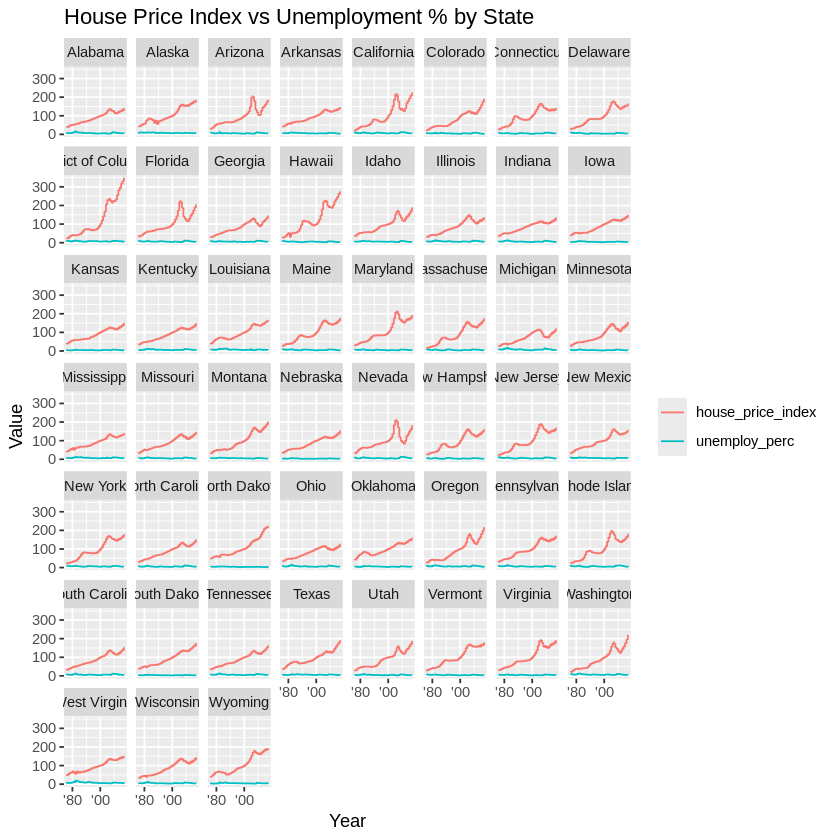

In [8]:
ggplot(house_reshaped, aes(x = year(date), y = value, color = measure)) +
  geom_line() +
  facet_wrap(~ state) +
  scale_x_continuous(breaks = c(1980, 2000, 2020), labels = c("'80", "'00", "'20")) +
  labs(title = "House Price Index vs Unemployment % by State",
       x = "Year", y = "Value") +
  theme(legend.title = element_blank())


In [9]:
house_prices %>%
  gather(key = measure, value = value, -c(house_price_index, date, state)) -> house_reshaped2


In [10]:
library(dplyr)
library(tidyr)

# Reshape while excluding house_price_index, date, and state from gathering
house_reshaped2 <- house_prices %>%
  gather(key = measure, value = value, -c(house_price_index, date, state))

# Preview the reshaped result
head(house_reshaped2)


date,state,house_price_index,measure,value
<date>,<chr>,<dbl>,<chr>,<dbl>
1976-01-01,Alabama,37.13829,unemploy_perc,6.7
1976-02-01,Alabama,37.75644,unemploy_perc,6.7
1976-03-01,Alabama,38.27632,unemploy_perc,6.6
1976-04-01,Alabama,38.59613,unemploy_perc,6.5
1976-05-01,Alabama,38.74052,unemploy_perc,6.4
1976-06-01,Alabama,38.79723,unemploy_perc,6.5


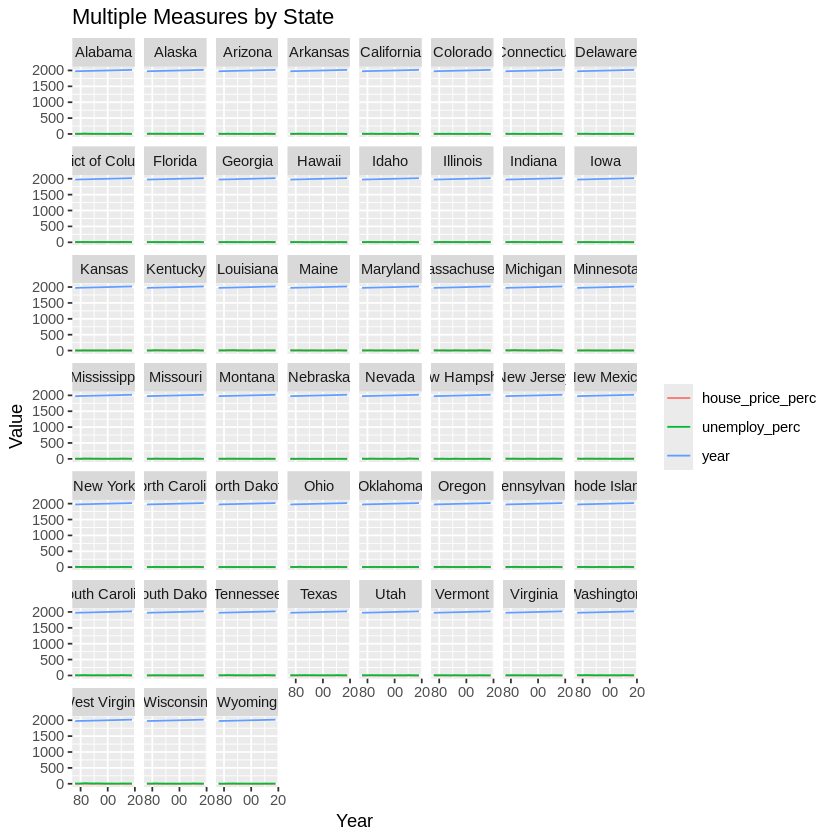

In [11]:
library(ggplot2)
library(lubridate)

ggplot(house_reshaped2, aes(x = date, y = value, color = measure)) +
  geom_line() +
  facet_wrap(~ state) +
  scale_x_continuous(
    breaks = ymd(c("1980-01-01", "2000-01-01", "2020-01-01")),
    labels = c("80", "00", "20")
  ) +
  labs(title = "Multiple Measures by State",
       x = "Year", y = "Value") +
  theme(legend.title = element_blank())


date,state,house_price_perc,year,measure,value
<date>,<chr>,<dbl>,<dbl>,<chr>,<dbl>
1976-01-01,Alabama,0.04040541,1976,house_price_index,37.13829
1976-02-01,Alabama,0.05180597,1976,house_price_index,37.75644
1976-03-01,Alabama,0.05930233,1976,house_price_index,38.27632
1976-04-01,Alabama,0.05958458,1976,house_price_index,38.59613
1976-05-01,Alabama,0.05572338,1976,house_price_index,38.74052
1976-06-01,Alabama,0.05359368,1976,house_price_index,38.79723


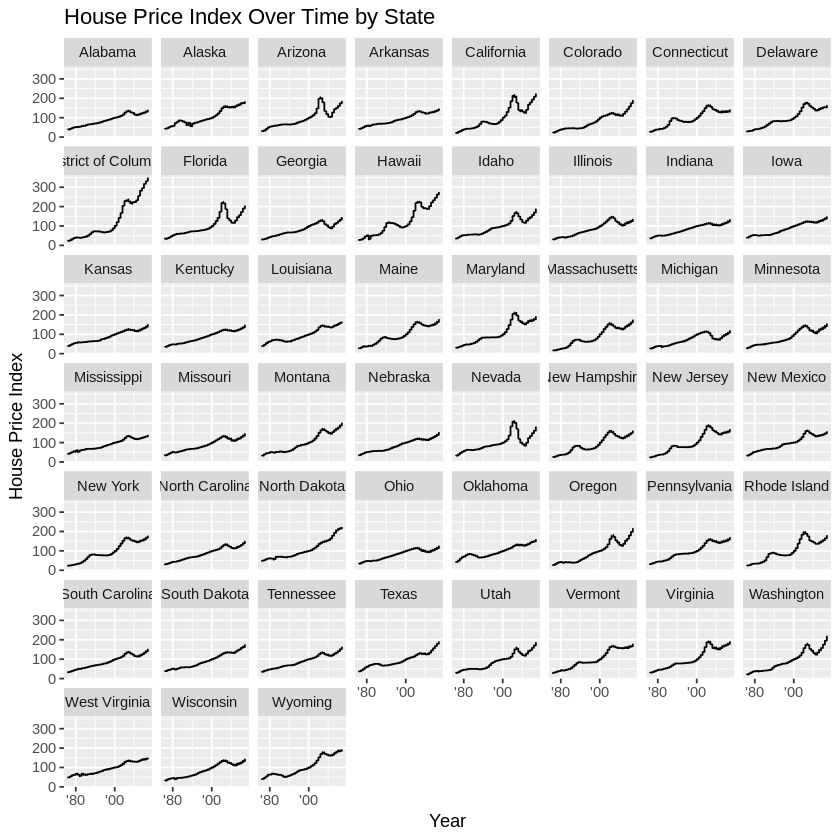

date,state,house_price_index,measure,value
<date>,<chr>,<dbl>,<chr>,<dbl>
1976-01-01,Alabama,37.13829,unemploy_perc,6.7
1976-02-01,Alabama,37.75644,unemploy_perc,6.7
1976-03-01,Alabama,38.27632,unemploy_perc,6.6
1976-04-01,Alabama,38.59613,unemploy_perc,6.5
1976-05-01,Alabama,38.74052,unemploy_perc,6.4
1976-06-01,Alabama,38.79723,unemploy_perc,6.5


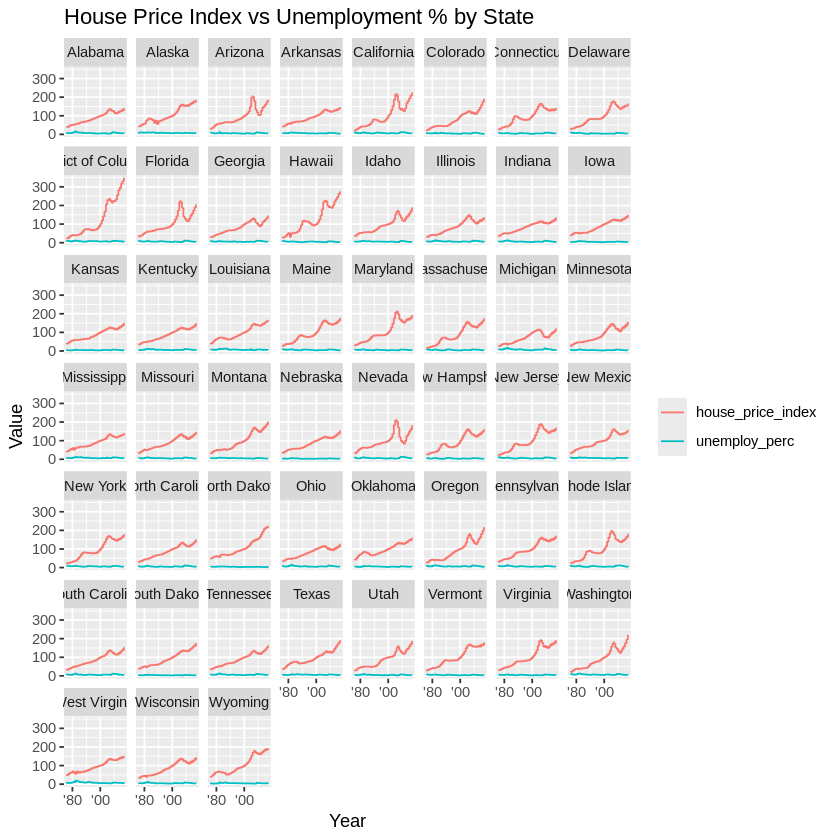

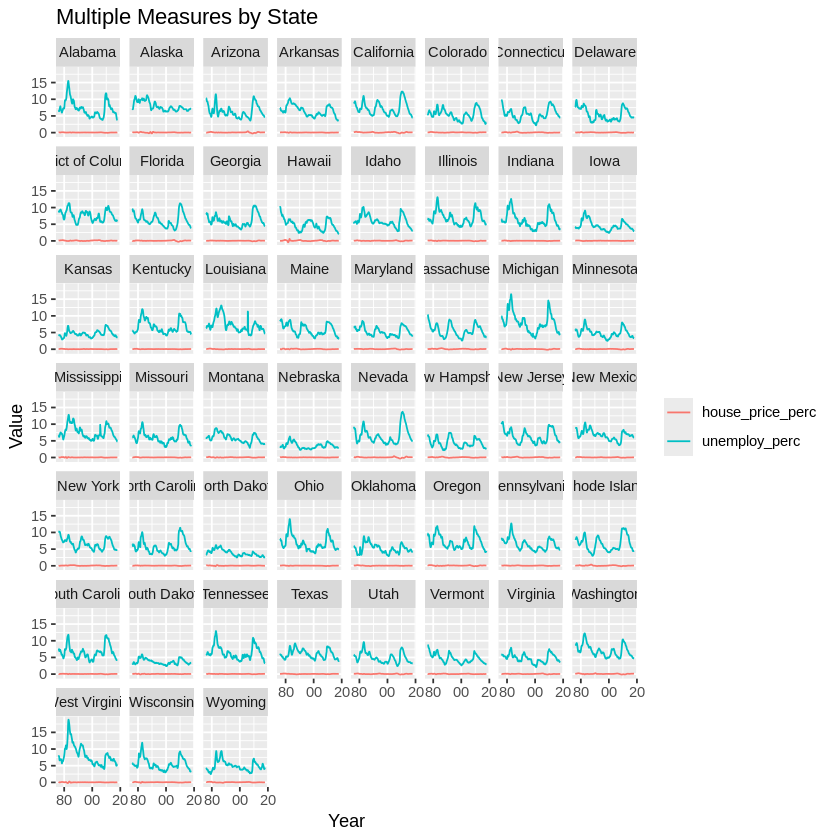

In [15]:
# Load required libraries
library(ggplot2)
library(tidyr)
library(dplyr)
library(lubridate)

# Load data
load("/content/drive/MyDrive/ColabFiles/house_prices.rda")

# -----------------------
# 1a. Faceted Line Plots of House Price Index
# -----------------------

# I added a 'year' column to make the x-axis easier to control
house_prices$year <- year(house_prices$date)

# I plotted house_price_index trends for each state using facet_wrap
ggplot(house_prices, aes(x = year, y = house_price_index)) +
  geom_line() +
  facet_wrap(~ state) +
  scale_x_continuous(breaks = c(1980, 2000, 2020),
                     labels = c("'80", "'00", "'20")) +
  labs(title = "House Price Index Over Time by State",
       x = "Year", y = "House Price Index")

# ----------------------------
# 1b. Reshape Data for Multiple Measures
# ----------------------------

# I reshaped the data so that house_price_index and unemploy_perc are combined into a long format
house_reshaped <- house_prices %>%
  gather(key = "measure", value = "value", house_price_index, unemploy_perc)

# I checked the reshaped result
head(house_reshaped)

# -------------------------------
# 1c. Compare House Price and Unemployment Trends
# -------------------------------

# This plot shows two lines per state: one for house price index, one for unemployment %
ggplot(house_reshaped, aes(x = year(date), y = value, color = measure)) +
  geom_line() +
  facet_wrap(~ state) +
  scale_x_continuous(breaks = c(1980, 2000, 2020),
                     labels = c("'80", "'00", "'20")) +
  labs(title = "House Price Index vs Unemployment % by State",
       x = "Year", y = "Value") +
  theme(legend.title = element_blank())

# My observation:
# This is a helpful comparison, but these two variables are on different scales.
# A normalized plot or dual-axis might improve interpretability.

# -------------------------------------------------
# 2. Reshape Other Measures Using Provided Gather Code
# -------------------------------------------------

# Before reshaping, I removed the year column to prevent it from being gathered
house_reshaped2 <- house_prices %>%
  select(-year) %>%
  gather(key = measure, value = value, -c(house_price_index, date, state))

# Preview reshaped data
head(house_reshaped2)

# --------------------------------------------------
# Final Plot: Multiple Measures Colored by Type
# --------------------------------------------------

# I used scale_x_date since we're working with actual dates here
ggplot(house_reshaped2, aes(x = date, y = value, color = measure)) +
  geom_line() +
  facet_wrap(~ state) +
  scale_x_date(breaks = ymd(c("1980-01-01", "2000-01-01", "2020-01-01")),
               labels = c("80", "00", "20")) +
  labs(title = "Multiple Measures by State",
       x = "Year", y = "Value") +
  theme(legend.title = element_blank())

# My final thoughts:
# This final transformation allowed me to view multiple metrics (e.g., unemploy_perc, house_perc)
# together across all states. Removing 'year' before gathering fixed the issue where it incorrectly
# appeared as a line in the legend.
